Question 03

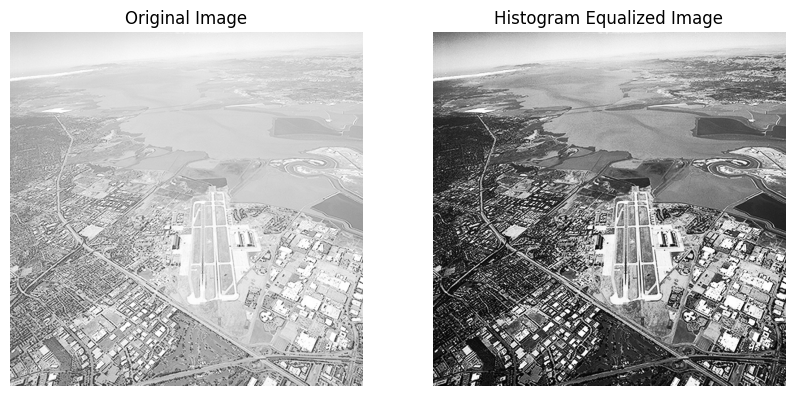

In [1]:
#function to equalize the histogram of an image

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def histogram_equalization(img):
    #flatten the image to 1D
    img_flat = img.flatten()

    #calculate histogram
    hist = np.zeros(256)
    for pixel in img_flat:
        hist[pixel] += 1

    #normalize histogram
    hist_norm = hist / np.sum(hist)

    #compute cumulative distribution function (CDF)
    cdf = np.cumsum(hist_norm)

    #create mapping function
    mapping = np.floor(255 * cdf).astype(np.uint8)
    #apply mapping to get equalized image
    img_equalized = mapping[img_flat].reshape(img.shape)
    return img_equalized

f = cv.imread('runway.png')
assert f is not None, "Image not found"

img_equalized = histogram_equalization(f)

# Display using matplotlib 
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(f, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Histogram Equalized Image")
plt.imshow(img_equalized, cmap='gray')
plt.axis('off')

plt.show()

